<a href="https://colab.research.google.com/github/jsansao/teic_tp_mock/blob/main/tp2_titanic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Trabalho Prático 2 (TP2) - Ciência de Dados
## Dataset: Titanic (Análise Exploratória e Engenharia de Features)

Este notebook apresenta a resolução da segunda etapa (TP2) para o dataset do Titanic. O foco desta etapa é a **Análise Exploratória de Dados (EDA)**, o pré-processamento de variáveis categóricas, o tratamento de dados ausentes e a fundamentação teórica para os passos seguintes de modelagem.

---

## 1. Revisão da Formalização do Problema e Objetivos

### 1.1 Resumo do Problema
O objetivo desta pesquisa é investigar e modelar os fatores que influenciaram a sobrevivência no naufrágio do RMS Titanic (1912). O problema é tratado como uma **classificação binária supervisionada**, mapeando atributos do passageiro em uma variável predita $Y \in \{0, 1\}$ (0 = Óbito, 1 = Sobrevivência).

### 1.2 Objetivos Pretendidos
*   Realizar uma análise estatística descritiva e visual das principais features.
*   Tratar de forma justificada e cientificamente embasada as variáveis categóricas e os dados ausentes.
*   Criar novas features a partir das existentes (Engenharia de Features) com base na literatura do problema.
*   Preparar a base limpa e escalonada para o treinamento de modelos tradicionais e profundos de aprendizado na próxima etapa (TP3).

---

## 2. Análise Exploratória dos Dados (EDA) e Transformações

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações de visualização
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Carregamento do dataset original
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

print(f"Dimensões do dataset: {df.shape[0]} linhas e {df.shape[1]} colunas.")
df.head()

Dimensões do dataset: 891 linhas e 12 colunas.


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### 2.1 A base de dados é adequada?
A base de dados é altamente adequada porque contém variáveis que correspondem diretamente aos fatores sociais e de logística da época do naufrágio, tais como sexo (priorização de mulheres), idade (crianças), classe do bilhete (localização física no navio e status socioeconômico) e vínculos familiares.

### 2.2 Existem dados faltantes?
Vamos inspecionar a presença de valores ausentes em cada coluna do DataFrame.

In [ ]:
# Verificação de dados faltantes (quantidade e porcentagem)
null_counts = df.isnull().sum()
null_percent = 100 * df.isnull().sum() / len(df)
null_table = pd.concat([null_counts, null_percent], axis=1, keys=['Valores Ausentes', '% do Total'])
null_table[null_table['Valores Ausentes'] > 0]

,Valores Ausentes,% do Total
Age,177,19.865320
Cabin,687,77.104377
Embarked,2,0.224467


#### Discussão e Tratamento dos Dados Faltantes:
1.  **Cabin (Cabine - 77.10% faltantes):** Devido ao altíssimo percentual de dados faltantes, a imputação seria ruidosa. A variável será **descartada** para evitar a inserção de vieses artificiais.
2.  **Age (Idade - 19.86% faltantes):** A idade é um fator biológico importante na sobrevivência. Em vez de simplesmente preencher com a média global (o que achataria a variância), vamos imputar os valores usando a **mediana da idade agrupada por classe (`Pclass`) e gênero (`Sex`)**, o que gera estimativas muito mais realistas.
3.  **Embarked (Porto de Embarque - 0.22% faltantes):** Apenas 2 registros estão ausentes. Serão preenchidos com a **moda** (Southampton), que é o porto mais comum.

In [ ]:
# Imputação de Embarked pela moda
most_frequent_port = df['Embarked'].mode()[0]
df['Embarked'] = df['Embarked'].fillna(most_frequent_port)

# Imputação de Age usando a mediana do grupo (Pclass, Sex)
df['Age'] = df.groupby(['Pclass', 'Sex'])['Age'].transform(lambda x: x.fillna(x.median()))

# Verificação se restam nulos
print("Quantidade de nulos após tratamento:", df.isnull().sum().sum())

Quantidade de nulos após tratamento: 687


### 2.3 Informações Estatísticas e Visualização das Features Principais

Vamos inspecionar o sumário descritivo dos atributos numéricos e criar visualizações para entender a correlação com a taxa de sobrevivência.

In [ ]:
# Estatísticas descritivas básicas
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.112424,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,13.304424,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,21.500000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,26.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,36.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


/tmp/ipykernel_762/1897732222.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Sex', y='Survived', palette='muted')


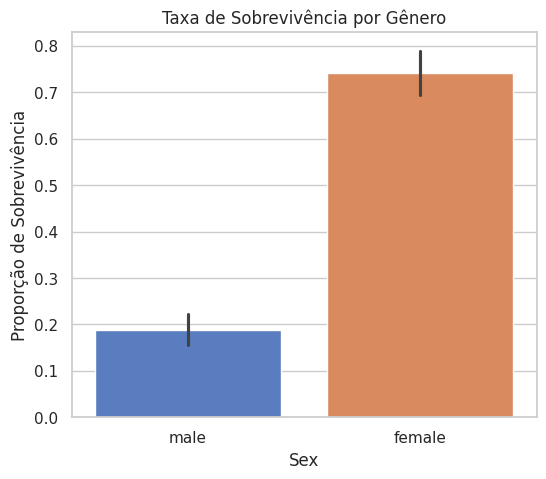

In [ ]:
# 1. Taxa de Sobrevivência por Gênero
plt.figure(figsize=(6, 5))
sns.barplot(data=df, x='Sex', y='Survived', palette='muted')
plt.title('Taxa de Sobrevivência por Gênero')
plt.ylabel('Proporção de Sobrevivência')
plt.show()

/tmp/ipykernel_762/3484269003.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Pclass', y='Survived', palette='deep')


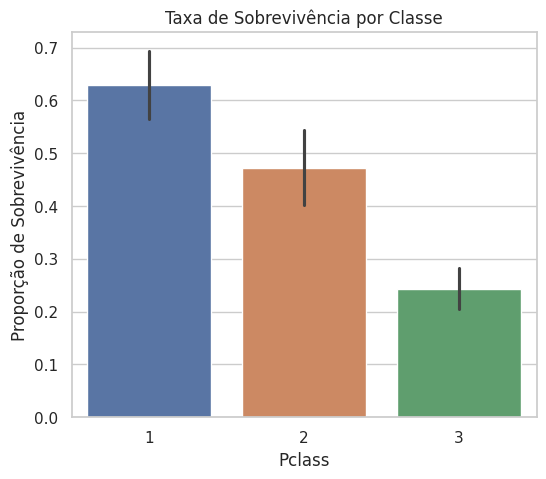

In [ ]:
# 2. Taxa de Sobrevivência por Classe do Bilhete
plt.figure(figsize=(6, 5))
sns.barplot(data=df, x='Pclass', y='Survived', palette='deep')
plt.title('Taxa de Sobrevivência por Classe')
plt.ylabel('Proporção de Sobrevivência')
plt.show()

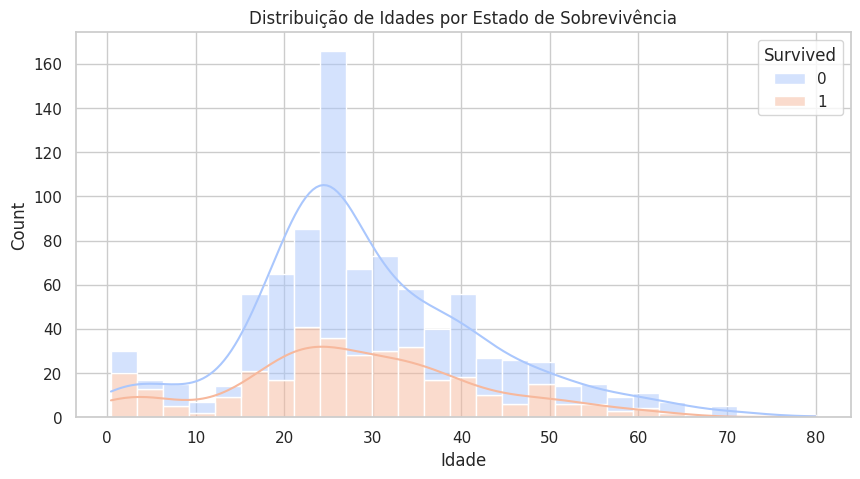

In [ ]:
# 3. Distribuição de Idades por Sobrevivência
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='Age', hue='Survived', kde=True, multiple='stack', palette='coolwarm')
plt.title('Distribuição de Idades por Estado de Sobrevivência')
plt.xlabel('Idade')
plt.show()

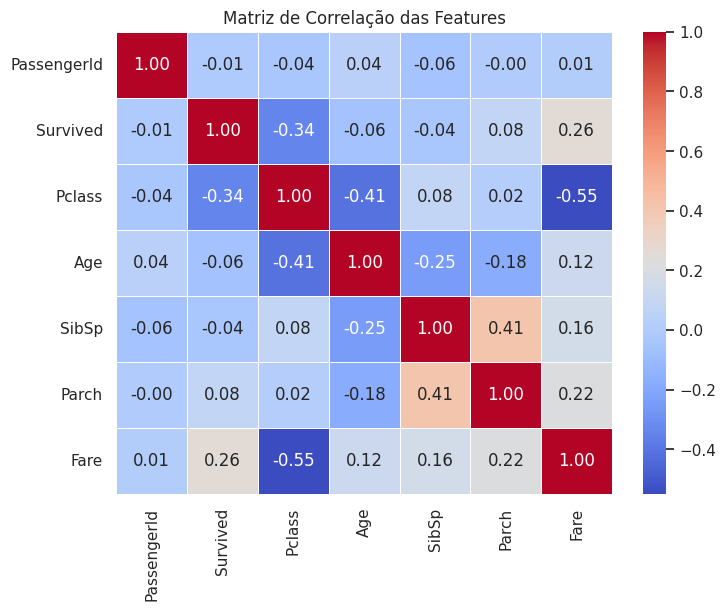

In [ ]:
# 4. Matriz de Correlação das Variáveis Numéricas
plt.figure(figsize=(8, 6))
numeric_cols = df.select_dtypes(include=[np.number]).columns
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlação das Features')
plt.show()

### 2.4 Variáveis Categóricas e Engenharia de Features

#### Criação de Novas Features:
1.  **FamilySize (Tamanho da Família):** Combinar as colunas `SibSp` (irmãos/cônjuges) e `Parch` (pais/filhos) mais o próprio passageiro ($SibSp + Parch + 1$).
2.  **IsAlone (Viaja Sozinho):** Variável binária que indica se o tamanho da família é igual a 1.

#### Codificação das Variáveis Categóricas:
*   `Sex`: Mapeado binariamente (0 = Macho, 1 = Fêmea).
*   `Embarked`: Aplicação de **One-Hot Encoding** (gerando variáveis dummy para as portas C, Q e S), já que não há relação de ordem.

In [ ]:
# Criação de features familiares
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

# Codificação de Sex (Label Encoding binário)
df['Sex_Encoded'] = df['Sex'].map({'male': 0, 'female': 1})

# Codificação de Embarked (One-Hot Encoding)
df = pd.get_dummies(df, columns=['Embarked'], prefix='Emb', drop_first=True)

# Remover colunas desnecessárias para a modelagem
columns_to_drop = ['PassengerId', 'Name', 'Sex', 'Ticket', 'Cabin']
df_processed = df.drop(columns=columns_to_drop)

# Converter colunas booleanas resultantes do get_dummies para 0/1 inteiro
for col in df_processed.columns:
    if df_processed[col].dtype == bool:
        df_processed[col] = df_processed[col].astype(int)

df_processed.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,FamilySize,IsAlone,Sex_Encoded,Emb_Q,Emb_S
0,0,3,22.0,1,0,7.2500,2,0,0,0,1
1,1,1,38.0,1,0,71.2833,2,0,1,0,0
2,1,3,26.0,0,0,7.9250,1,1,1,0,1
3,1,1,35.0,1,0,53.1000,2,0,1,0,1
4,0,3,35.0,0,0,8.0500,1,1,0,0,1


### 2.5 Normalização / Escalamento das Features Numéricas
Como os algoritmos que pretendemos usar na próxima etapa incluem modelos lineares (como Regressão Logística) e Redes Neurais (MLP), é crucial colocar variáveis numéricas contínuas com magnitudes muito diferentes (`Age` e `Fare`) na mesma escala. Utilizaremos a padronização **StandardScaler** para obter média 0 e desvio padrão 1.

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_processed[['Age', 'Fare']] = scaler.fit_transform(df_processed[['Age', 'Fare']])

print("Dataset final pré-processado e escalonado:")
df_processed.head()

Dataset final pré-processado e escalonado:


,Survived,Pclass,Age,SibSp,Parch,Fare,FamilySize,IsAlone,Sex_Encoded,Emb_Q,Emb_S
0,0,3,-0.534891,1,0,-0.502445,2,0,0,0,1
1,1,1,0.668392,1,0,0.786845,2,0,1,0,0
2,1,3,-0.234070,0,0,-0.488854,1,1,1,0,1
3,1,1,0.442776,1,0,0.420730,2,0,1,0,1
4,0,3,0.442776,0,0,-0.486337,1,1,0,0,1


---

## 3. Principais Decisões de Projeto

### 3.1 Descrição das Decisões
1.  **Imputação por Mediana do Grupo:** Em vez de usar a mediana simples sobre `Age`, agrupamos por gênero e classe socioeconômica. Isso preserva melhor a distribuição real, visto que passageiros da 1ª classe historicamente tinham idades medianas mais altas que os da 3ª classe.
2.  **Criação de Features Familiares:** A unificação de `SibSp` e `Parch` em `FamilySize` e `IsAlone` condensa a informação de estrutura familiar, facilitando o aprendizado de árvores de decisão.
3.  **Remoção de Colunas de Alta Cardinalidade:** Descartamos `Cabin`, `Name` e `Ticket` nesta fase por possuírem alta cardinalidade textual e excessivos nulos, o que causaria overfitting em modelos simples.
4.  **Escalonamento Z-score (StandardScaler):** Essencial para o bom comportamento da Regressão Logística e redes neurais MLP no TP3.

### 3.2 Revisão da Literatura
*   **Simonoff (1997)** demonstra que a modelagem preditiva no Titanic se beneficia imensamente da engenharia de features familiares e da inclusão da classe como regressor categorizado.
*   Múltiplos projetos no **Kaggle** indicam que a criação do atributo `IsAlone` ajuda modelos de árvore de decisão a separar rapidamente indivíduos solteiros do sexo masculino, que apresentavam as menores taxas de sobrevivência.

### 3.3 Avaliação do Impacto na Próxima Etapa
No TP3, avaliaremos o impacto dessas decisões treinando os modelos em duas versões de dados:
*   *Versão A:* Apenas as variáveis cruas limpas, sem engenharia de atributos (`FamilySize`, `IsAlone`).
*   *Versão B:* O dataset processado com engenharia de atributos.
Mediremos a diferença de Acurácia e F1-Score para validar o ganho gerado pelas transformações feitas neste TP2.

---

## 4. Metodologia de Modelagem e Simulação Computacional (TP3)

### 4.1 Algoritmos de Machine / Deep Learning Pretendidos
Para a próxima etapa de modelagem manual, selecionamos três algoritmos representativos de diferentes paradigmas:
1.  **Regressão Logística (LR):** Modelo linear estatístico, ideal como baseline interpretável.
2.  **Random Forest (RF):** Modelo baseado em ensemble de árvores de decisão que captura interações não-lineares sem necessitar de suposições de linearidade.
3.  **Rede Neural Multicamadas (MLP Classifier):** Modelo de Deep Learning básico para avaliar o potencial de representação não linear complexa.

### 4.2 Métricas de Desempenho
Utilizaremos um conjunto robusto de métricas:
*   **Acurácia:** Proporção global de acertos.
*   **Precisão e Recall (Revocação):** Para mitigar o impacto do leve desbalanceamento do target.
*   **F1-Score:** Média harmônica balanceando precisão e recall.
*   **Área sob a Curva ROC (AUC-ROC):** Para medir a capacidade de discriminação probabilística do modelo.

### 4.3 Referências de Comparação
Os resultados obtidos de forma manual no TP3 serão confrontados diretamente com:
1.  O baseline trivial da **moda** (Acurácia: ~61.6%).
2.  A Prova de Conceito automática de AutoML obtida via **FLAML no TP1** (Acurácia: ~80-82%). O objetivo é verificar se a modelagem manual com ajuste fino de hiperparâmetros supera ou se equipara ao AutoML automático.
